In [1]:
import os
import random
import h5py

import pandas as pd
import numpy as np

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
import torchvision.models as models
from torchinfo import summary
from sklearn.metrics import r2_score
import plotly.express as px


from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split


import torchvision.transforms.functional as TF

import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="ticks", palette="pastel", rc={"lines.linewidth": 2.5})

SEED = 1998
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
if hasattr(torch.backends, "cudnn"):
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
try:
    torch.use_deterministic_algorithms(True)
except Exception:
    pass

generator = torch.Generator().manual_seed(SEED)

# Set the device to use for training
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

In [2]:
folder_path = "models/"

# Create the folder path and checkpoints directory if they don't exist
if not os.path.exists(folder_path):
    os.makedirs(folder_path)

if not os.path.exists(os.path.join(folder_path, "checkpoints")):
    os.makedirs(os.path.join(folder_path, "checkpoints"))

# modify so indices is the index of the dataframe
def read_hdf5_to_dataframe_with_index(h5_path="unified_parallel.h5"):
    with h5py.File(h5_path, "r") as f:
        viirs_start = f["viirs_start"][:]
        viirs_end = f["viirs_end"][:]
        rgb = f["rgb"][:]
        figures = f["figures"][:]
        indices = f["indices"][:]
        iso3 = f["iso3"][:]
        types = f["type"][:]

    # Decode bytes to strings for iso3
    iso3_decoded = [x.decode("utf-8") if isinstance(x, bytes) else x for x in iso3]
    types_decoded = [x.decode("utf-8") if isinstance(x, bytes) else x for x in types]

    # Create a DataFrame with indices as the index
    df = pd.DataFrame(
        {
            "viirs_start": list(viirs_start),
            "viirs_end": list(viirs_end),
            "rgb": list(rgb),
            "figures": figures,
            "iso3": iso3_decoded,
            "type": types_decoded,
        },
        index=indices,
    )

    df.sort_index(inplace=True)  # Ensure indices are sorted

    return df

path = "../src/data/processed/disaster.h5"
df_disaster = read_hdf5_to_dataframe_with_index(path)

path_idu = "../src/data/processed/testing.h5"
df_idu = read_hdf5_to_dataframe_with_index(path_idu)

# load csv iso3 embeddings
iso3_embeddings = pd.read_csv("../src/data/processed/embeddings_mapped.csv", index_col=0)

# combine the two dataframes
df = pd.concat([df_disaster, df_idu], ignore_index=True)

del df_disaster
del df_idu



# Simple baseline

- model a (emb+type)

Report saved to: Model_Performance_Analysis.pdf

Top 5 Countries (Model B R2):
iso3
AFG    0.763534
SYR    0.709034
BGD    0.682347
CRI    0.569640
RUS    0.440067
dtype: float64

R2 by Type:
type
Mixed disasters        0.830661
Earthquake             0.477178
Erosion                0.465819
Flood                  0.426368
Storm                  0.407932
Volcanic activity      0.396757
Mass Movement          0.313547
Drought                0.281956
Wildfire               0.164032
Extreme Temperature   -3.024090
dtype: float64


/var/folders/ys/5gn1z90x7c1_khtjpp5kg6580000gn/T/ipykernel_72467/1759800681.py:232: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  r2_by_country = results_df.groupby('iso3', observed=True).apply(safe_r2).dropna().sort_values(ascending=False)
/var/folders/ys/5gn1z90x7c1_khtjpp5kg6580000gn/T/ipykernel_72467/1759800681.py:233: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  r2_by_type = results_df.groupby('type', observed=

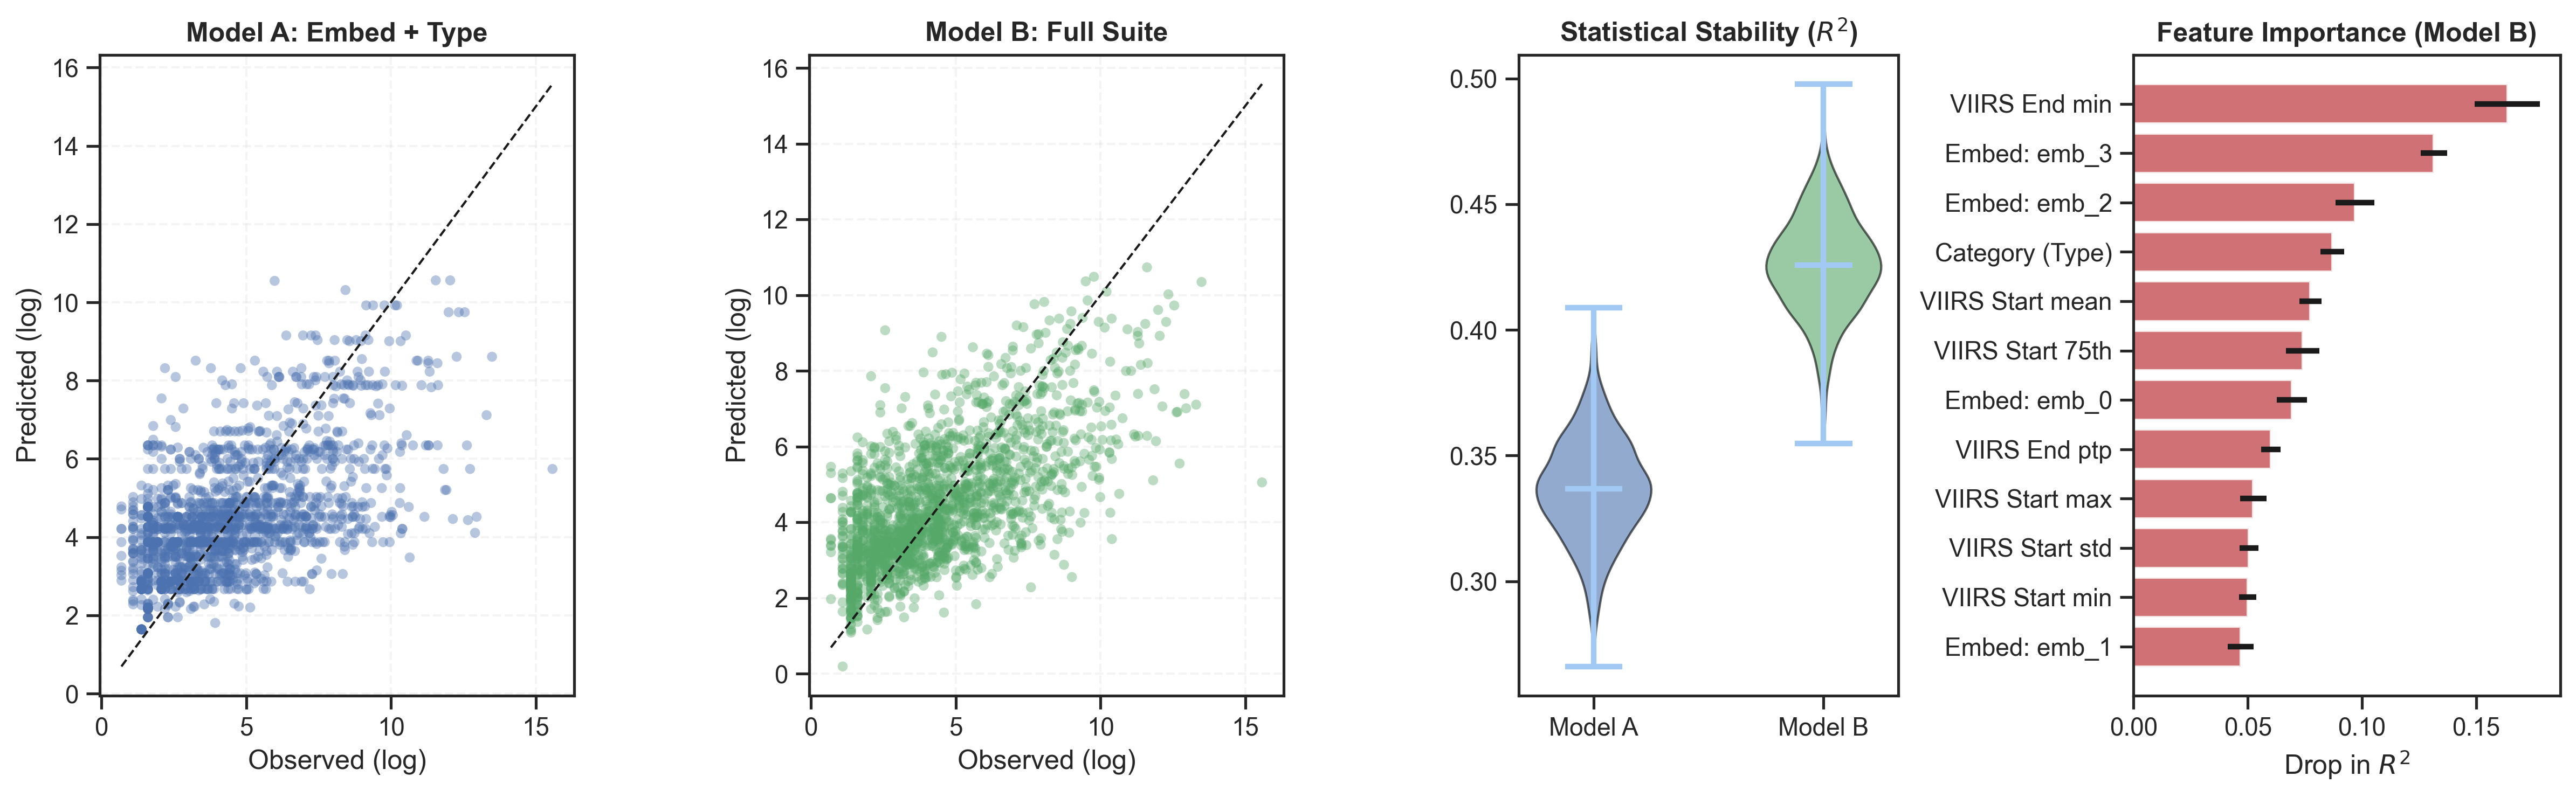

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
from xgboost import XGBRegressor

# =========================================================
# CONFIG
# =========================================================
RANDOM_STATE = 42
TEST_SIZE = 0.1
BOOTSTRAP_ITERS = 1000

# =========================================================
# 1. FEATURE ENGINEERING MODULE
# =========================================================
def get_image_stats(image_array):
    """Extracts 8 statistical moments from an image array."""
    if image_array is None or len(image_array) == 0:
        return np.zeros(8)
    try:
        img = np.array(image_array)
        if img.size == 0: return np.zeros(8)
        flat = img.flatten()
        return np.array([
            np.mean(flat), np.std(flat), np.min(flat), np.max(flat),
            np.percentile(flat, 25), np.percentile(flat, 50),
            np.percentile(flat, 75), np.ptp(flat)
        ])
    except:
        return np.zeros(8)

def process_image_columns(df, columns_map):
    """Processes multiple image columns into a single feature DataFrame."""
    all_stats = []
    for col, prefix in columns_map.items():
        stats = df[col].apply(get_image_stats)
        stat_df = pd.DataFrame(np.array(stats.tolist()), 
                               columns=[f"{prefix}_{i}" for i in range(8)])
        all_stats.append(stat_df)
    return pd.concat(all_stats, axis=1)

def prepare_features(df, iso3_embeddings):
    """
    Merges embeddings and prepares categorical types.
    Model A features: iso3 embeddings + categorical type.
    """
    embedding_df = iso3_embeddings.reset_index().rename(
        columns={iso3_embeddings.index.name or "index": "iso3"}
    )
    merged = df.merge(embedding_df, on="iso3", how="inner")
    
    # Set 'type' as categorical for native XGBoost support
    merged["type"] = merged["type"].astype("category")
    
    img_map = {"viirs_start": "vs", "viirs_end": "ve", "rgb": "rgb"}
    img_features = process_image_columns(merged, img_map)
    
    embed_cols = [c for c in embedding_df.columns if c != "iso3"]
    
    # Model A: Embeddings + Categorical Type
    features_a = embed_cols + ["type"]
    
    # Full Feature Set (including 'iso3' for tracking, not training)
    X_full_df = pd.concat([
        merged[["iso3", "type"]], 
        merged[embed_cols], 
        img_features
    ], axis=1)
    
    # Ensure columns are unique after concat
    X_full_df = X_full_df.loc[:, ~X_full_df.columns.duplicated()]
    
    y = merged["figures"].to_numpy(np.float32)
    
    return X_full_df, y, features_a

# =========================================================
# 2. MODELING MODULE
# =========================================================
def get_xgb_regressor():
    """Returns XGBoost with categorical support enabled."""
    return XGBRegressor(
        objective="reg:squarederror",
        n_estimators=5000,
        learning_rate=0.03,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        early_stopping_rounds=100,
        enable_categorical=True, # Handles pandas 'category' type
        tree_method="hist"       # Required for categorical support
    )

def run_bootstrap_analysis(y_true, y_pred, n_iterations=BOOTSTRAP_ITERS):
    """Calculates distribution of metrics via bootstrapping."""
    stats = {"R2": [], "MAE": [], "RMSE": []}
    rng = np.random.default_rng(RANDOM_STATE)
    for _ in range(n_iterations):
        idx = rng.choice(len(y_true), size=len(y_true), replace=True)
        y_t, y_p = y_true[idx], y_pred[idx]
        stats["R2"].append(r2_score(y_t, y_p))
        stats["MAE"].append(mean_absolute_error(y_t, y_p))
        stats["RMSE"].append(np.sqrt(mean_squared_error(y_t, y_p)))
    return pd.DataFrame(stats)

# =========================================================
# 3. VISUALIZATION MODULE
# =========================================================
def format_feature_labels(feature_names):
    """Converts internal codes to human-readable labels."""
    stat_map = {0:"mean", 1:"std", 2:"min", 3:"max", 4:"25th", 5:"50th", 6:"75th", 7:"ptp"}
    labels = []
    for f in feature_names:
        if f == "type": labels.append("Category (Type)")
        elif any(f.startswith(p) for p in ["vs_","ve_","rgb_"]):
            p, i = f.split("_")
            p_map = {"vs":"VIIRS Start", "ve":"VIIRS End", "rgb":"RGB"}
            labels.append(f"{p_map[p]} {stat_map[int(i)]}")
        else: labels.append(f"Embed: {f}")
    return labels

def export_performance_pdf(y_test, pred_dict, boot_dict, imp_df, output_path="Analysis_Report.pdf"):
    """Generates diagnostic plots and saves to PDF."""
    plt.rcParams.update({"font.family": "sans-serif", "font.size": 9})
    fig = plt.figure(figsize=(16, 5), dpi=300)
    gs = GridSpec(1, 4, width_ratios=[1, 1, 0.8, 0.9])

    colors = ["#4C72B0", "#55A868"]
    
    # Panels 1 & 2: Scatter Plots
    for i, (name, y_pred) in enumerate(pred_dict.items()):
        ax = fig.add_subplot(gs[0, i])
        ax.scatter(y_test, y_pred, s=20, alpha=0.4, color=colors[i], edgecolors='none')
        ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "--k", lw=1)
        ax.set_title(name, weight='bold')
        ax.set_xlabel("Observed (log)")
        ax.set_ylabel("Predicted (log)")
        ax.grid(True, linestyle="--", alpha=0.2)

    # Panel 3: R2 Stability
    ax_boot = fig.add_subplot(gs[0, 2])
    v = ax_boot.violinplot([boot_dict["A"]["R2"], boot_dict["B"]["R2"]], showmedians=True)
    for i, pc in enumerate(v['bodies']):
        pc.set_facecolor(colors[i]); pc.set_edgecolor('black'); pc.set_alpha(0.6)
    ax_boot.set_xticks([1, 2]); ax_boot.set_xticklabels(["Model A", "Model B"])
    ax_boot.set_title("Statistical Stability ($R^2$)", weight='bold')

    # Panel 4: Feature Importance
    ax_imp = fig.add_subplot(gs[0, 3])
    top_imp = imp_df.head(12).iloc[::-1]
    ax_imp.barh(top_imp["display_name"], top_imp["importance_mean"], 
                xerr=top_imp["importance_std"], color="#C44E52", alpha=0.8)
    ax_imp.set_title("Feature Importance (Model B)", weight='bold')
    ax_imp.set_xlabel("Drop in $R^2$")

    plt.tight_layout()
    plt.savefig(output_path, format='pdf', bbox_inches='tight')
    print(f"Report saved to: {output_path}")

# =========================================================
# MAIN EXECUTION
# =========================================================
if __name__ == "__main__":
    # 1. Feature Prep
    X_full, y, features_a = prepare_features(df, iso3_embeddings)
    y_log = np.log1p(y)
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_full, y_log, test_size=TEST_SIZE, random_state=RANDOM_STATE
    )

    # Define Full Feature Set for Model B (all except ID columns)
    features_b = [c for c in X_full.columns if c not in ["iso3"]]

    # 2. Training
    model_a = get_xgb_regressor()
    model_a.fit(X_train[features_a], y_train, 
                eval_set=[(X_test[features_a], y_test)], verbose=False)
    
    model_b = get_xgb_regressor()
    model_b.fit(X_train[features_b], y_train, 
                eval_set=[(X_test[features_b], y_test)], verbose=False)

    # 3. Evaluation
    preds_a = model_a.predict(X_test[features_a])
    preds_b = model_b.predict(X_test[features_b])
    
    boot_a = run_bootstrap_analysis(y_test, preds_a)
    boot_b = run_bootstrap_analysis(y_test, preds_b)

    # 4. Importance (Model B)
    imp = permutation_importance(model_b, X_test[features_b], y_test, 
                                 n_repeats=10, random_state=RANDOM_STATE)
    
    imp_df = pd.DataFrame({
        "feature": features_b,
        "importance_mean": imp.importances_mean,
        "importance_std": imp.importances_std
    }).sort_values("importance_mean", ascending=False)
    imp_df["display_name"] = format_feature_labels(imp_df["feature"])

    # 5. Export
    export_performance_pdf(
        y_test = y_test,
        pred_dict = {"Model A: Embed + Type": preds_a, "Model B: Full Suite": preds_b},
        boot_dict = {"A": boot_a, "B": boot_b},
        imp_df = imp_df,
        output_path = "Model_Performance_Analysis.pdf"
    )

    # 6. Post-Analysis
    results_df = pd.DataFrame({
        'iso3': X_test['iso3'],
        'type': X_test['type'],
        'y_true': y_test,
        'y_pred_B': preds_b
    })

    def safe_r2(g):
        return r2_score(g['y_true'], g['y_pred_B']) if len(g) > 1 else np.nan

    r2_by_country = results_df.groupby('iso3', observed=True).apply(safe_r2).dropna().sort_values(ascending=False)
    r2_by_type = results_df.groupby('type', observed=True).apply(safe_r2).dropna().sort_values(ascending=False)
    
    print("\nTop 5 Countries (Model B R2):")
    print(r2_by_country.head(5))
    print("\nR2 by Type:")
    print(r2_by_type)

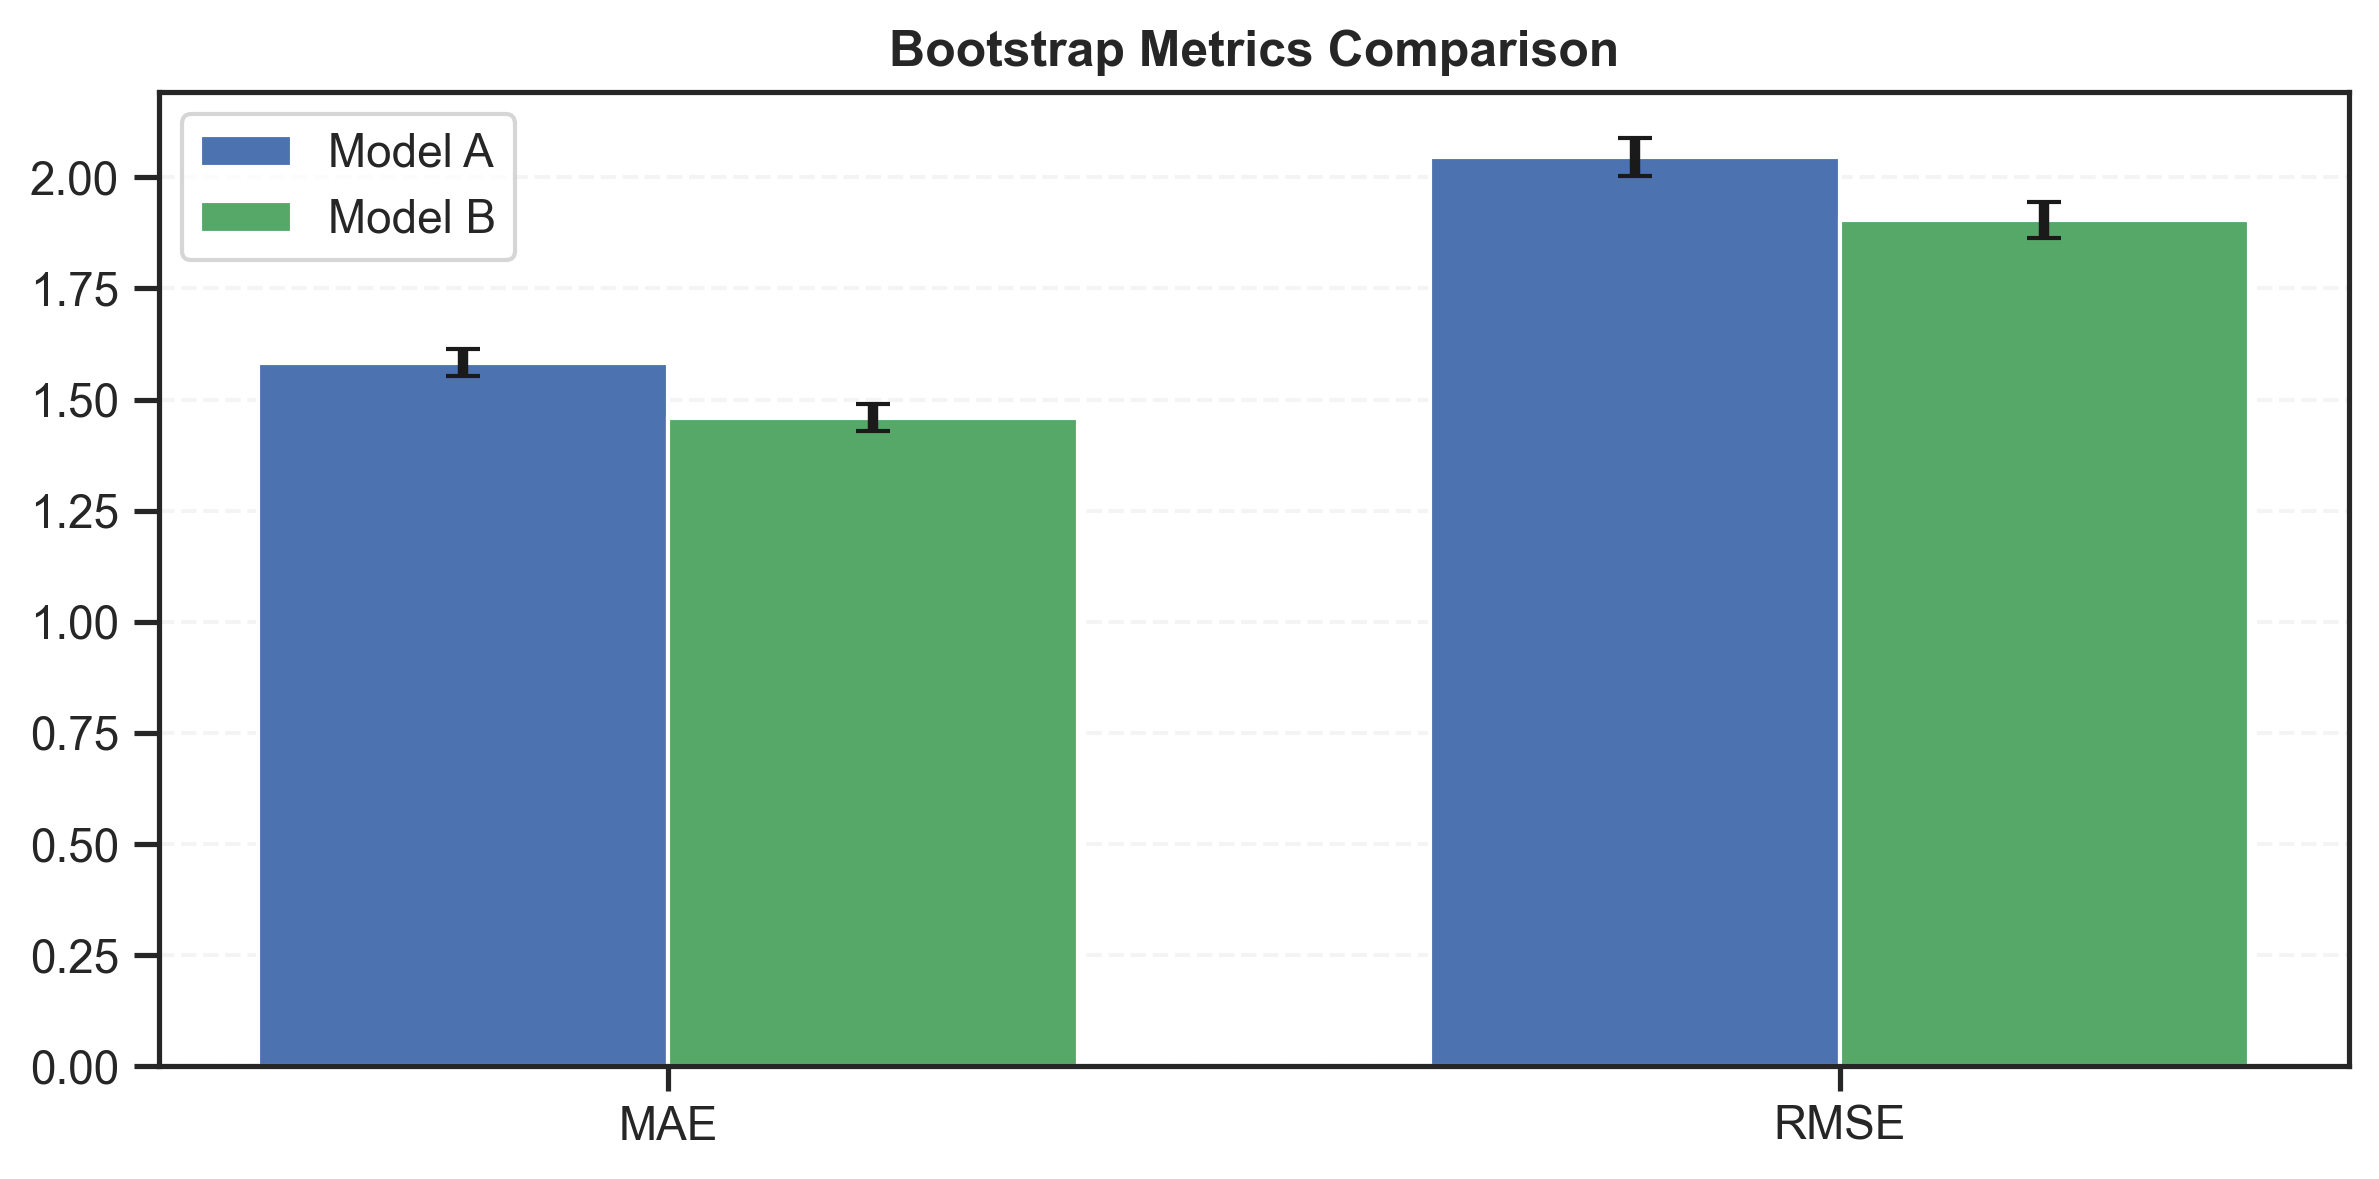

In [4]:
def plot_mae_rmse_bootstrap(boot_a, boot_b):
    """Plots bootstrap summary statistics as bar charts with error bars."""
    metrics = ["MAE", "RMSE"]
    means_a = [boot_a[m].mean() for m in metrics]
    std_a = [boot_a[m].std() for m in metrics]
    means_b = [boot_b[m].mean() for m in metrics]
    std_b = [boot_b[m].std() for m in metrics]

    x = np.arange(len(metrics))
    width = 0.35

    fig, ax = plt.subplots(figsize=(8, 4), dpi=300)

    ax.bar(x - width / 2, means_a, width, yerr=std_a, capsize=4, label="Model A", color="#4C72B0")
    ax.bar(x + width / 2, means_b, width, yerr=std_b, capsize=4, label="Model B", color="#55A868")

    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    ax.set_title("Bootstrap Metrics Comparison", weight="bold")
    ax.grid(True, axis="y", linestyle="--", alpha=0.2)
    ax.legend()

    plt.tight_layout()
    plt.show()

plot_mae_rmse_bootstrap(boot_a, boot_b)

In [5]:
import plotly.graph_objects as go

SUBTLE_GREY = "#737373"

# --- Data ---
df = (
    r2_by_type.reset_index(name="r2")
    .merge(results_df.groupby("type").size().reset_index(name="count"), on="type")
    .sort_values("r2")
)

colors = df["r2"].apply(lambda x: "#252525" if x > 0 else "#cb181d")

# --- Figure ---
fig = go.Figure(
    go.Bar(
        y=df["type"],
        x=df["r2"],
        orientation="h",
        width=0.6,
        marker=dict(color=colors, line=dict(color="black", width=1)),
        text=[f"{r:.2f} <span style='color:{SUBTLE_GREY};'>(n={n})</span>"
              for r, n in zip(df["r2"], df["count"])],
        textposition="outside",
        cliponaxis=False,
    )
)

# --- Layout ---
fig.update_layout(
    template="simple_white",
    height=450,
    width=900,
    margin=dict(l=20, r=150, t=60, b=60),
    font=dict(family="Arial", size=12, color="black"),
    title=dict(
        text="Predictive Performance by Disaster Category",
        x=0.02,
        font=dict(size=16),
    ),
)

fig.update_xaxes(
    title="R² Score",
    zeroline=True,
    zerolinewidth=1.5,
    zerolinecolor="black",
    showline=True,
    linecolor="black",
)

fig.update_yaxes(
    title="",
    automargin=True,
)

fig.write_image("Performance_Nature_Left_Aligned.pdf", engine="kaleido")
fig.show()

/var/folders/ys/5gn1z90x7c1_khtjpp5kg6580000gn/T/ipykernel_72467/2830838144.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .merge(results_df.groupby("type").size().reset_index(name="count"), on="type")
/var/folders/ys/5gn1z90x7c1_khtjpp5kg6580000gn/T/ipykernel_72467/2830838144.py:57: DeprecationWarning: 
Support for the 'engine' argument is deprecated and will be removed after September 2025.
Kaleido will be the only supported engine at that time.

  fig.write_image("Performance_Nature_Left_Aligned.pdf", engine="kaleido")


Using real results_df.
Saved: per_country_metrics.csv


/var/folders/ys/5gn1z90x7c1_khtjpp5kg6580000gn/T/ipykernel_72467/2535598145.py:82: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  metrics["R2"] = df.groupby("iso3", observed=True).apply(safe_r2).values
/var/folders/ys/5gn1z90x7c1_khtjpp5kg6580000gn/T/ipykernel_72467/2535598145.py:163: DeprecationWarning: 
Support for the 'engine' argument is deprecated and will be removed after September 2025.
Kaleido will be the only supported engine at that time.

  fig_map.write_image("per_country_mae_map.pdf", engine="kaleido")


feat NOT subset; don't know how to subset; dropped
fond NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


Saved: per_country_mae_map.html / .pdf


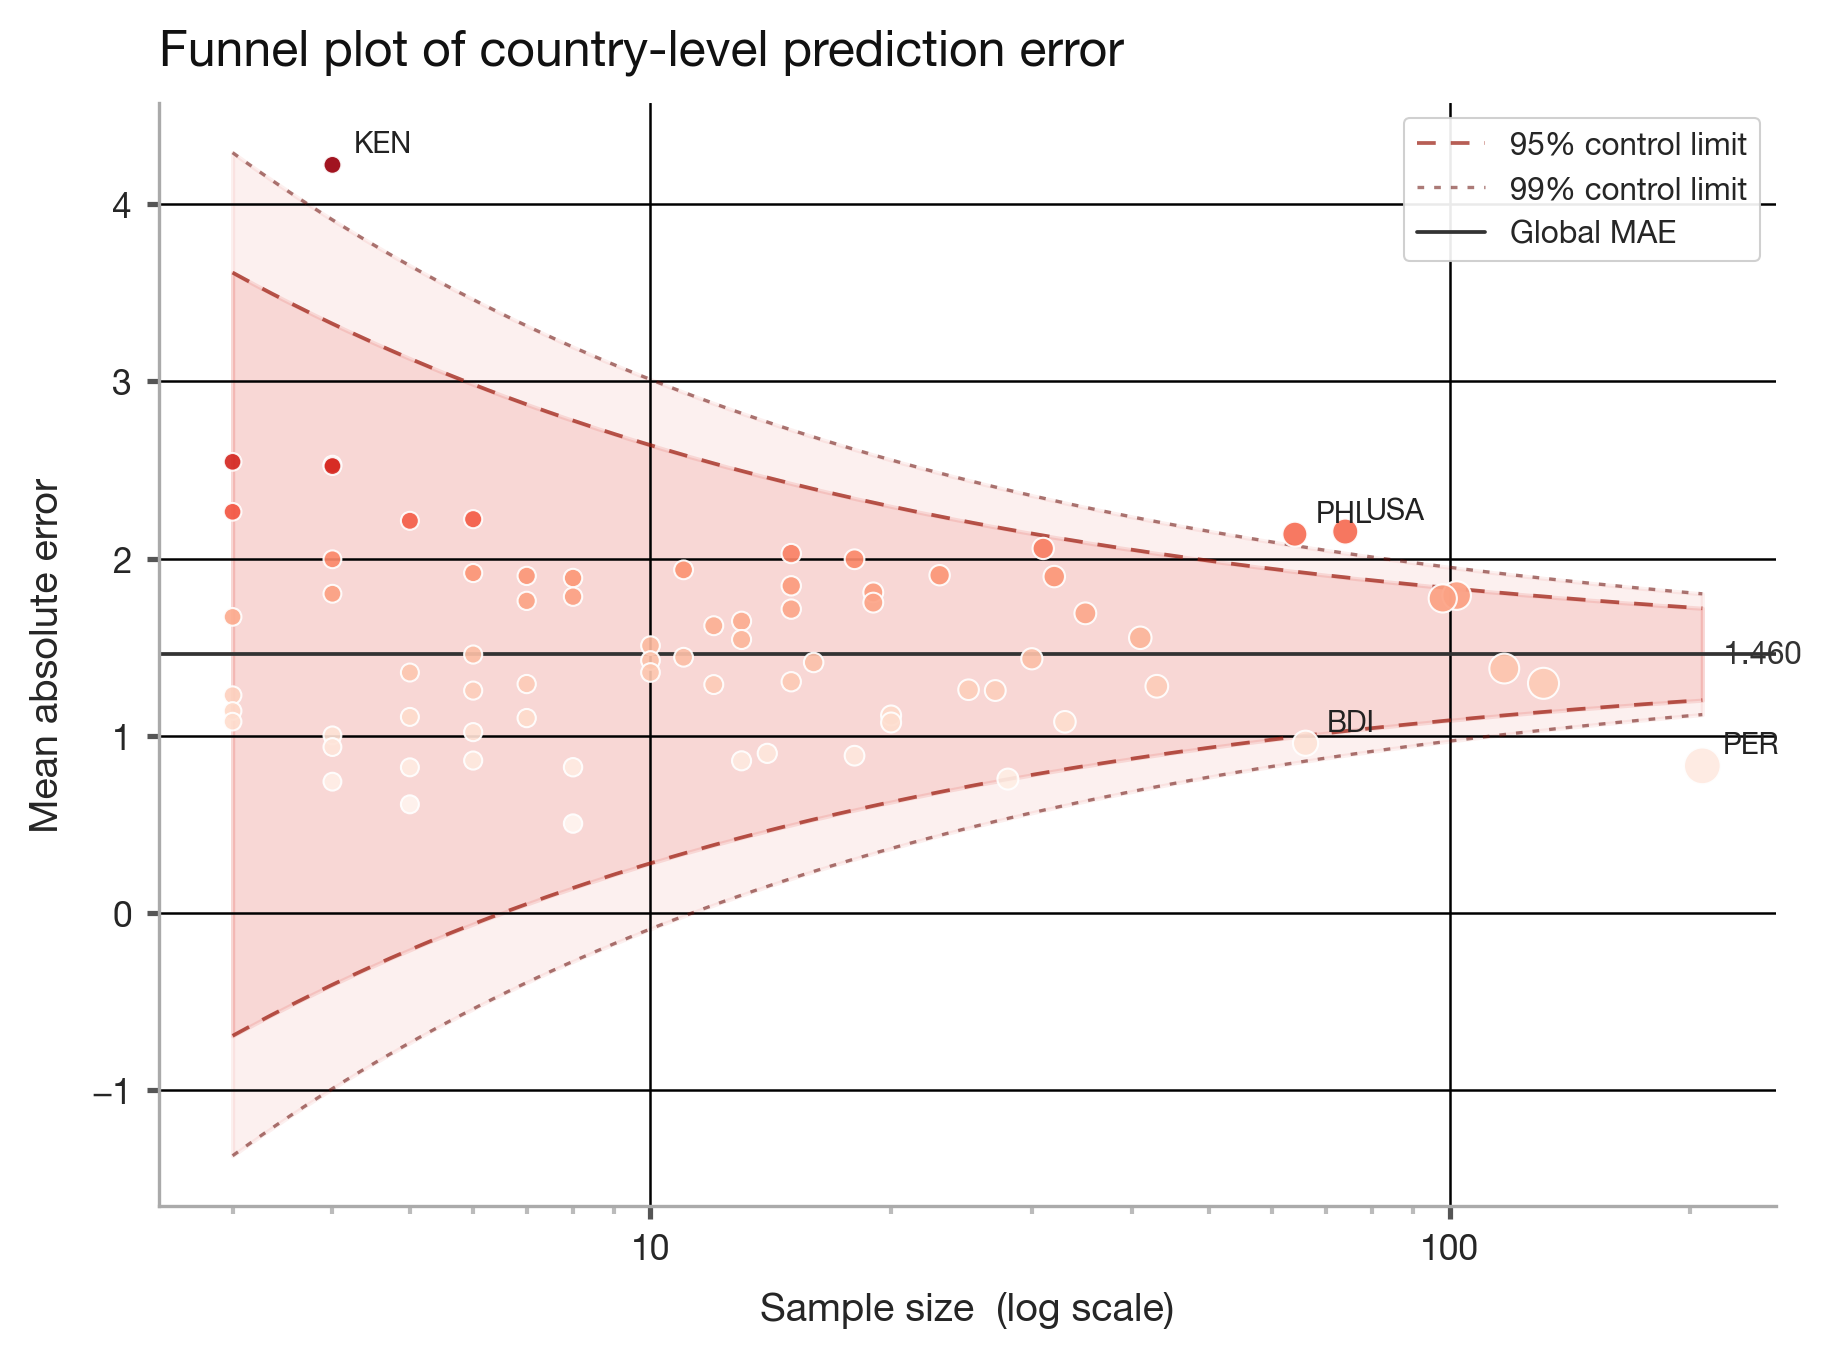

Saved: per_country_error_funnel.pdf / .png

Worst-performing countries by MAE:
iso3  n      MAE     RMSE  MedianAE        R2
 TZA  1 4.503689 4.503689  4.503689       NaN
 KEN  4 4.223387 4.388403  3.846707 -4.274802
 POL  2 4.193867 4.526555  4.193867       NaN
 GUM  2 3.488769 3.518723  3.488769       NaN
 LBN  2 3.148915 3.274367  3.148915       NaN
 COM  2 3.144769 3.278079  3.144769       NaN
 MDA  1 2.735895 2.735895  2.735895       NaN
 MDG  3 2.546140 2.994094  3.012133 -1.548297
 HUN  2 2.537628 2.552438  2.537628       NaN
 GEO  4 2.530084 2.553225  2.709881 -1.897030

Saved: worst_countries_table.csv


In [6]:
"""
Nature-style per-country error diagnostics.
  - expects results_df with cols: iso3, y_true, y_pred_B
  Falls back to simulated data if globals are absent.
"""

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
import plotly.graph_objects as go
from sklearn.metrics import r2_score

# ── Shared style constants ────────────────────────────────────────────────────
mpl.rcParams.update({
    "font.family":      "sans-serif",
    "font.sans-serif":  ["Helvetica Neue", "Helvetica", "Arial", "DejaVu Sans"],
    "pdf.fonttype":     42,
    "ps.fonttype":      42,
    "axes.spines.top":  False,
    "axes.spines.right":False,
})

NATURE_RED = mcolors.LinearSegmentedColormap.from_list(
    "nature_red",
    ["#fff5f0", "#fee0d2", "#fcbba1", "#fc9272", "#ef3b2c", "#99000d"],
)

SPINE_COLOR = "#aaaaaa"
GRID_COLOR  = (0, 0, 0, 0.09)

# ── 0. Data ───────────────────────────────────────────────────────────────────
try:
    df = results_df.assign(
        y_obs  = lambda d: d["y_true"],
        y_pred = lambda d: d["y_pred_B"],
    ).copy()
    print("Using real results_df.")

except NameError:
    print("⚠  results_df not found — using simulated data.\n")
    rng = np.random.default_rng(42)
    countries = [
        "SSD","CAF","YEM","HTI","SOM","COD","SDN","NER","MLI","TCD",
        "NGA","ETH","UGA","MOZ","ZMB","KEN","TZA","GHA","SEN","CMR",
        "MDG","BFA","GIN","SLE","MWI","RWA","BDI","ERI","DJI","COM",
    ]
    rows = []
    for iso in countries:
        n = rng.integers(8, 60)
        bias = rng.uniform(-0.3, 0.3)
        noise = rng.uniform(0.15, 0.55)
        y_true = rng.uniform(0.5, 4.5, n)
        y_pred = y_true + bias + rng.normal(0, noise, n)
        rows.append(pd.DataFrame({"iso3": iso, "y_true": y_true, "y_pred_B": y_pred}))
    results_df = pd.concat(rows, ignore_index=True)
    df = results_df.assign(y_obs=lambda d: d["y_true"], y_pred=lambda d: d["y_pred_B"]).copy()

df["residual"]  = df["y_obs"] - df["y_pred"]
df["abs_error"] = df["residual"].abs()
df["sq_error"]  = df["residual"] ** 2

# ── 1. Country-level metrics ──────────────────────────────────────────────────
def safe_r2(g):
    yt, yp = g["y_obs"], g["y_pred"]
    return r2_score(yt, yp) if len(g) >= 3 and yt.nunique() > 1 else np.nan

metrics = (
    df.groupby("iso3", observed=True)
    .agg(
        n          = ("residual",  "size"),
        MAE        = ("abs_error", "mean"),
        RMSE       = ("sq_error",  lambda x: np.sqrt(x.mean())),
        MedianAE   = ("abs_error", "median"),
        MeanObs    = ("y_obs",     "mean"),
        StdObs     = ("y_obs",     "std"),
    )
    .reset_index()
)
metrics["R2"] = df.groupby("iso3", observed=True).apply(safe_r2).values
metrics = metrics.sort_values("MAE", ascending=False).reset_index(drop=True)

metrics.to_csv("per_country_metrics.csv", index=False)
print("Saved: per_country_metrics.csv")


# ════════════════════════════════════════════════════════════════════════════
# FIGURE A — Choropleth (Plotly, Nature-styled)
# ════════════════════════════════════════════════════════════════════════════
vmin = float(metrics["MAE"].quantile(0.05))
vmax = float(metrics["MAE"].quantile(0.95))

# Build Plotly-compatible colorscale from our cmap
_pts = np.linspace(0, 1, 12)
plotly_scale = [
    [t, mcolors.to_hex(NATURE_RED(t))] for t in _pts
]

fig_map = go.Figure(go.Choropleth(
    locations       = metrics["iso3"],
    z               = metrics["MAE"],
    zmin            = vmin,
    zmax            = vmax,
    colorscale      = plotly_scale,
    locationmode    = "ISO-3",
    marker_line_color = "white",
    marker_line_width = 0.4,
    colorbar = dict(
        title       = dict(text="MAE", font=dict(size=11, family="Helvetica")),
        thickness   = 12,
        len         = 0.55,
        x           = 1.01,
        ticks       = "outside",
        ticklen     = 3,
        tickfont    = dict(size=9, family="Helvetica"),
        outlinewidth= 0.5,
    ),
    customdata = np.column_stack([
        metrics["RMSE"].round(3),
        metrics["R2"].round(3),
        metrics["n"],
    ]),
    hovertemplate = (
        "<b>%{location}</b><br>"
        "MAE:  %{z:.3f}<br>"
        "RMSE: %{customdata[0]:.3f}<br>"
        "R²:   %{customdata[1]:.3f}<br>"
        "n:    %{customdata[2]}<extra></extra>"
    ),
))

fig_map.update_layout(
    template = "simple_white",
    height   = 460,
    width    = 960,
    margin   = dict(l=0, r=10, t=64, b=10),
    font     = dict(family="Helvetica Neue, Helvetica, Arial", size=11, color="#1a1a1a"),
    title    = dict(
        text      = "<b>Per-country prediction error (MAE)</b>",
        x         = 0.01,
        xanchor   = "left",
        font      = dict(size=15),
    ),
    geo = dict(
        showframe      = False,
        showcoastlines = True,
        coastlinecolor = "#cccccc",
        coastlinewidth = 0.5,
        showland       = True,
        landcolor      = "#f5f5f5",
        showocean      = True,
        oceancolor     = "#eef3f7",
        showlakes      = False,
        showcountries  = False,
        projection_type= "natural earth",
        bgcolor        = "rgba(0,0,0,0)",
    ),
)

fig_map.write_html("per_country_mae_map.html")
fig_map.write_image("per_country_mae_map.pdf", engine="kaleido")
fig_map.show()
print("Saved: per_country_mae_map.html / .pdf")


# ════════════════════════════════════════════════════════════════════════════
# FIGURE B — Funnel plot (matplotlib, Nature-styled)
# ════════════════════════════════════════════════════════════════════════════
global_std = float(df["residual"].std())
global_mae = float(df["abs_error"].mean())

n_plot = metrics[metrics["n"] >= 3].copy()
n_space = np.logspace(
    np.log10(n_plot["n"].clip(lower=1).min()),
    np.log10(n_plot["n"].max()),
    300,
)
control_95 = 1.96 * global_std / np.sqrt(n_space)
control_99 = 2.576 * global_std / np.sqrt(n_space)

# Colour dots by MAE using the same scale
mae_norm  = mcolors.Normalize(vmin=vmin, vmax=vmax)
dot_colors = [NATURE_RED(mae_norm(m)) for m in n_plot["MAE"]]

fig, ax = plt.subplots(figsize=(6.2, 4.6), dpi=300)

# 99% band (outer, very faint fill)
ax.fill_between(
    n_space,
    global_mae - control_99,
    global_mae + control_99,
    color=(0.88, 0.20, 0.16, 0.07),
    zorder=0,
)
# 95% band (inner fill)
ax.fill_between(
    n_space,
    global_mae - control_95,
    global_mae + control_95,
    color=(0.88, 0.20, 0.16, 0.13),
    zorder=0,
)

# 95% boundary lines
ax.plot(n_space, global_mae + control_95,
        color=(0.6, 0.1, 0.05, 0.70), lw=0.9,
        ls=(0, (5, 4)), label="95% control limit")
ax.plot(n_space, global_mae - control_95,
        color=(0.6, 0.1, 0.05, 0.70), lw=0.9,
        ls=(0, (5, 4)))

# 99% boundary lines
ax.plot(n_space, global_mae + control_99,
        color=(0.4, 0.05, 0.03, 0.55), lw=0.8,
        ls=(0, (2, 3)), label="99% control limit")
ax.plot(n_space, global_mae - control_99,
        color=(0.4, 0.05, 0.03, 0.55), lw=0.8,
        ls=(0, (2, 3)))

# Global MAE reference
ax.axhline(global_mae, color="#333333", lw=0.9, ls="-", zorder=1, label="Global MAE")

# Scatter — size proportional to sample size for added info
sizes = 18 + 60 * (n_plot["n"] - n_plot["n"].min()) / (n_plot["n"].max() - n_plot["n"].min() + 1)
sc = ax.scatter(
    n_plot["n"], n_plot["MAE"],
    c=n_plot["MAE"], cmap=NATURE_RED, norm=mae_norm,
    s=sizes,
    edgecolors="white", linewidths=0.5,
    zorder=3, alpha=0.92,
)

# Label outliers (outside 95% band)
out_band = 1.96 * global_std / np.sqrt(n_plot["n"])
outliers = n_plot[(n_plot["MAE"] > global_mae + out_band) |
                  (n_plot["MAE"] < global_mae - out_band)]

for _, row in outliers.iterrows():
    ax.annotate(
        row["iso3"],
        xy=(row["n"], row["MAE"]),
        xytext=(5, 3), textcoords="offset points",
        fontsize=7, color="#222222",
        arrowprops=None,
    )

# ── Axes styling ──────────────────────────────────────────────────────────────
ax.set_xscale("log")
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax.xaxis.set_minor_formatter(mticker.NullFormatter())
ax.tick_params(axis="both", which="major", labelsize=8.5, length=3, color="#555")
ax.tick_params(axis="x",    which="minor", length=2,     color="#bbb")

ax.set_xlabel("Sample size  (log scale)", fontsize=9.5, fontweight="bold", labelpad=6)
ax.set_ylabel("Mean absolute error",      fontsize=9.5, fontweight="bold", labelpad=6)

ax.set_title("Funnel plot of country-level prediction error",
             fontsize=12, fontweight="bold", loc="left", pad=9, color="#111")

for sp in ["left", "bottom"]:
    ax.spines[sp].set_color(SPINE_COLOR)
    ax.spines[sp].set_linewidth(0.8)

ax.xaxis.grid(True, color=GRID_COLOR, linewidth=0.6, zorder=0)
ax.yaxis.grid(True, color=GRID_COLOR, linewidth=0.6, zorder=0)
ax.set_axisbelow(True)

# Legend
leg = ax.legend(
    fontsize=7.5,
    frameon=True,
    framealpha=0.92,
    edgecolor="#cccccc",
    handlelength=2.2,
    loc="upper right",
)
leg.get_frame().set_linewidth(0.5)

# Annotation: global MAE value
ax.text(
    n_space[-1] * 1.01, global_mae,
    f"  {global_mae:.3f}",
    va="center", ha="left", fontsize=7.5,
    color="#333", fontstyle="italic",
)

plt.tight_layout()
plt.savefig("per_country_error_funnel.pdf", bbox_inches="tight", dpi=300)
plt.savefig("per_country_error_funnel.png", bbox_inches="tight", dpi=300)
plt.show()
print("Saved: per_country_error_funnel.pdf / .png")


# ── Worst-performers summary ──────────────────────────────────────────────────
worst = metrics.head(10)
worst.to_csv("worst_countries_table.csv", index=False)
print("\nWorst-performing countries by MAE:")
print(worst[["iso3", "n", "MAE", "RMSE", "MedianAE", "R2"]].to_string(index=False))
print("\nSaved: worst_countries_table.csv")

feat NOT subset; don't know how to subset; dropped
fond NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


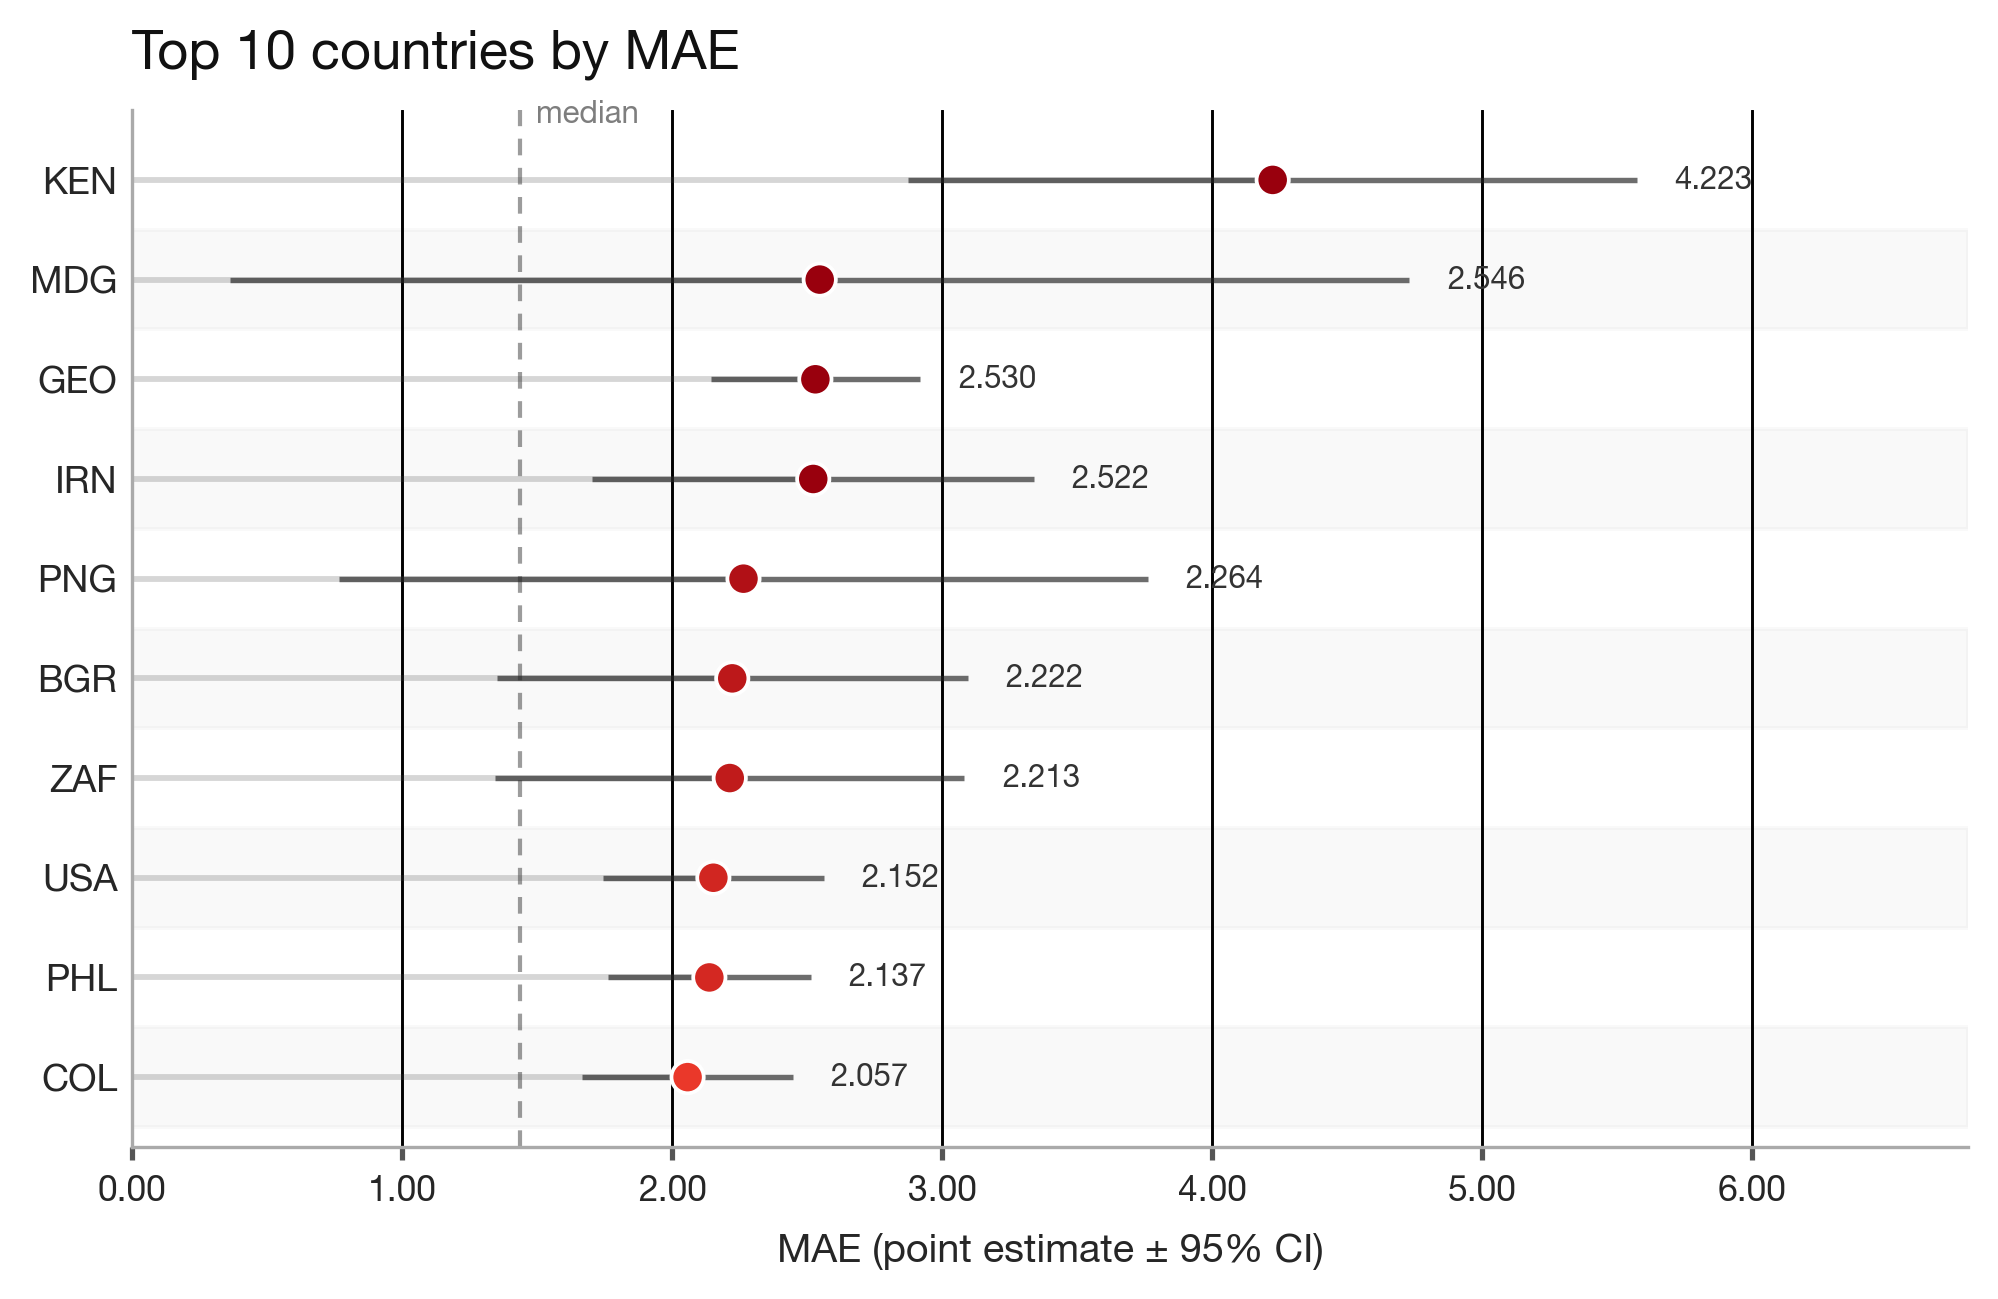

Saved: Per_Country_MAE_Top10_Nature.pdf
Saved: Per_Country_MAE_Top10_Nature.png


In [7]:
"""
Nature-style Top-10 MAE lollipop plot (pure matplotlib).

Drop-in compatible with the original Plotly script:
  - expects `metrics` (DataFrame with cols: iso3, R2)
  - expects `results_df` (DataFrame with cols: iso3, y_true, y_pred_B)
  If those globals aren't present, simulated data is used automatically.
"""

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ── 0. Font setup (Helvetica → fallback to DejaVu if unavailable) ────────────
mpl.rcParams.update({
    "font.family":      "sans-serif",
    "font.sans-serif":  ["Helvetica Neue", "Helvetica", "Arial", "DejaVu Sans"],
    "pdf.fonttype":     42,   # embeds fonts properly in PDF
    "ps.fonttype":      42,
    "axes.spines.top":  False,
    "axes.spines.right":False,
})

# ── 1. Data ───────────────────────────────────────────────────────────────────
try:
    # ---- real data path ----
    err_df = results_df.copy()
    err_df["abs_error"] = (err_df["y_true"] - err_df["y_pred_B"]).abs()

    mae_stats = (
        err_df.groupby("iso3", observed=True)["abs_error"]
        .agg(MAE="mean", n="size", sd="std")
        .reset_index()
    )
    mae_stats["sd"]     = mae_stats["sd"].fillna(0.0)
    mae_stats["mae_se"] = mae_stats["sd"] / np.sqrt(mae_stats["n"].clip(lower=1))
    mae_stats["ci95"]   = 1.96 * mae_stats["mae_se"]

    plot_df = (
        metrics[["iso3", "R2"]]
        .merge(mae_stats[["iso3", "MAE", "n", "ci95"]], on="iso3", how="right")
        .dropna(subset=["iso3", "MAE", "n"])
    )
    plot_df = plot_df[plot_df["n"] >= 3].copy()

except NameError:
    # ---- simulated data (demo) ----
    print("⚠  metrics/results_df not found — using simulated data.\n")
    plot_df = pd.DataFrame({
        "iso3":  ["SSD","CAF","YEM","HTI","SOM","COD","SDN","NER","MLI","TCD"],
        "MAE":   [0.891,0.843,0.812,0.779,0.751,0.726,0.698,0.664,0.631,0.603],
        "ci95":  [0.112,0.098,0.134,0.087,0.143,0.076,0.105,0.091,0.118,0.082],
        "n":     [14, 18, 11, 22, 9, 31, 17, 24, 13, 28],
        "R2":    [0.31,0.38,0.29,0.42,0.25,0.51,0.36,0.44,0.33,0.47],
    })

TOP_K      = 10
MEDIAN_MAE = float(plot_df["MAE"].median())

worst = (
    plot_df.sort_values("MAE", ascending=False)
    .head(TOP_K)
    .sort_values("MAE", ascending=True)   # ascending for horizontal bar (bottom = lowest)
    .reset_index(drop=True)
)

# ── 2. Colour map (white → deep red, Nature sequential) ──────────────────────
cmap = mcolors.LinearSegmentedColormap.from_list(
    "nature_red",
    ["#fff5f0","#fee0d2","#fcbba1","#fc9272","#ef3b2c","#99000d"],
)
vmin = float(plot_df["MAE"].quantile(0.05))
vmax = float(plot_df["MAE"].quantile(0.95))
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
colors = [cmap(norm(m)) for m in worst["MAE"]]

# ── 3. Layout ─────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(8.5, 4.8), dpi=300)
ax  = fig.add_axes([0.11, 0.13, 0.72, 0.72])   # [left, bottom, width, height]

y_pos = np.arange(len(worst))

# ── 4. Lollipop stems ─────────────────────────────────────────────────────────
ax.hlines(
    y=y_pos,
    xmin=0,
    xmax=worst["MAE"],
    colors=(0.27, 0.27, 0.27, 0.22),
    linewidths=1.4,
    zorder=1,
)

# ── 5. Error bars (CI whiskers, no caps) ─────────────────────────────────────
ax.errorbar(
    x=worst["MAE"],
    y=y_pos,
    xerr=worst["ci95"],
    fmt="none",
    ecolor=(0.12, 0.12, 0.12, 0.65),
    elinewidth=1.3,
    capsize=0,
    zorder=2,
)

# ── 6. Dots ───────────────────────────────────────────────────────────────────
sc = ax.scatter(
    worst["MAE"],
    y_pos,
    c=worst["MAE"],
    cmap=cmap,
    norm=norm,
    s=60,
    zorder=3,
    edgecolors="white",
    linewidths=0.9,
)

# ── 7. MAE value labels (right of CI whisker) ────────────────────────────────
x_max = float((worst["MAE"] + worst["ci95"]).max())
label_pad = x_max * 0.025

for _, row in worst.iterrows():
    ax.text(
        row["MAE"] + row["ci95"] + label_pad,
        row.name,
        f'{row["MAE"]:.3f}',
        va="center",
        ha="left",
        fontsize=7.5,
        color="#333333",
    )

# ── 8. Median reference line ─────────────────────────────────────────────────
ax.axvline(
    MEDIAN_MAE,
    color=(0.08, 0.08, 0.08, 0.42),
    linewidth=1.0,
    linestyle=(0, (4, 3)),   # custom dash
    zorder=0,
)
ax.text(
    MEDIAN_MAE + x_max * 0.01,
    y_pos[-1] + 0.52,
    "median",
    fontsize=7.5,
    fontstyle="italic",
    color=(0.08, 0.08, 0.08, 0.55),
    va="bottom",
)

# ── 9. Axes styling ───────────────────────────────────────────────────────────
ax.set_yticks(y_pos)
ax.set_yticklabels(worst["iso3"], fontsize=9)
ax.set_ylim(-0.7, len(worst) - 0.3)
ax.set_xlim(0, x_max * 1.22)

ax.set_xlabel("MAE (point estimate ± 95% CI)", fontsize=9.5, fontweight="bold", labelpad=6)
ax.xaxis.set_major_formatter(mpl.ticker.FormatStrFormatter("%.2f"))
ax.tick_params(axis="x", labelsize=8.5, length=3, color="#555")
ax.tick_params(axis="y", length=0)

ax.spines["left"].set_color("#aaaaaa")
ax.spines["bottom"].set_color("#aaaaaa")
ax.spines["left"].set_linewidth(0.8)
ax.spines["bottom"].set_linewidth(0.8)

ax.xaxis.grid(True, color=(0, 0, 0, 0.09), linewidth=0.7, zorder=0)
ax.set_axisbelow(True)

# alternating row shading
for i in range(len(worst)):
    if i % 2 == 0:
        ax.axhspan(i - 0.5, i + 0.5, color=(0, 0, 0, 0.025), zorder=0)

# ── 10. Title ─────────────────────────────────────────────────────────────────
ax.set_title(
    f"Top {TOP_K} countries by MAE",
    fontsize=13,
    fontweight="bold",
    loc="left",
    pad=10,
    color="#111111",
)

# ── 11. Save & show ───────────────────────────────────────────────────────────
OUT_PDF  = "Per_Country_MAE_Top10_Nature.pdf"
OUT_PNG  = "Per_Country_MAE_Top10_Nature.png"

fig.savefig(OUT_PDF, bbox_inches="tight", dpi=300)
fig.savefig(OUT_PNG, bbox_inches="tight", dpi=300)
plt.show()

print(f"Saved: {OUT_PDF}")
print(f"Saved: {OUT_PNG}")
